# Ranking pages with weak CTR for their Google position

**Subject: CTR / Engagement Opportunity Scoring**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rimlazrek1/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

Numbers below load from committed receipts in `work/outputs/` and charts in `work/figures/` . No warehouse pull is required to re-run this notebook.

---

## Abstract

Editors must decide which pages to review first when click-through rate looks weak relative to similar Google ranks. Using March 2026 page-level search performance from the FlyRank ML Internship dataset (~101k pages; ~62k with at least 500 impressions), we compare a transparent `ctr_gap` ranking rule to logistic regression scored on a client holdout. On the same eligible holdout pool (base rate 46.4%), the rule reaches Precision@50 = 1.00 by construction, while the model reaches 0.84 and surfaces high-impression, non-zero-CTR underperformers the rule buries. The output is a decision-support review queue with action archetypes — not a claim that editing a page will raise clicks, and not a prediction of Google’s ranking algorithm.

## 1. Introduction / Problem

**Research question.** Which pages get shown in Google but attract fewer clicks than peers in the same position tier — and which of those should a reviewer open first?

**Decision supported.** An editor or SEO reviewer chooses a short daily list of pages to inspect. For each page they may rewrite title/meta, improve content match, check tracking, or leave the page alone.

**Why a ranked score helps.** Raw CTR alone misleads: expected CTR falls sharply from top ranks to deep ranks, and thin-impression pages produce noisy CTR. Comparing CTR within `position_tier` and requiring enough impressions reduces that noise. Wrong calls still cost time (false alarms) or bury fixable pages (misses).

**Claim ladder.** Results are **observed / measured / directional / decision-support**. We do not claim that a rewrite caused more clicks, and we do not claim to have predicted Google’s algorithm.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

candidates = [
    Path("..") / "outputs",          # cwd = work/notebooks
    Path("work") / "outputs",        # cwd = repo root
    Path("outputs"),                 # cwd = work
    Path.cwd() / "work" / "outputs",
]
OUT = next((p.resolve() for p in candidates if p.exists()), None)
if OUT is None:
    raise FileNotFoundError("Could not find work/outputs from " + str(Path.cwd()))
ROOT = OUT.parent
FIG = ROOT / "figures"

playbook = json.loads((OUT / "playbook_metrics.json").read_text())
model_vs = json.loads((OUT / "model_vs_baseline_metrics.json").read_text())
baseline = json.loads((OUT / "baseline_metrics.json").read_text())
leakage = json.loads((OUT / "validation_leakage_trap.json").read_text())
claims = json.loads((OUT / "validation_claim_rewrite.json").read_text())

print("Lane:", playbook["lane"])
print("Slice:", playbook["slice"])
print("Pages in March frame:", playbook["n_pages"])
print("Eligible baseline pool (imp>=500):", baseline["n"])
print("Random seed (model):", model_vs["random_state"])

Lane: Lane 4 CTR opportunity
Slice: month=2026-03
Pages in March frame: 101441
Eligible baseline pool (imp>=500): 61924
Random seed (model): 42


## 2. Data

**Source.** FlyRank ML Internship warehouse (public internship release). Primary table: `fact_content_daily_performance`, aggregated to one row per page for **`month=2026-03`**. Optional joins to content/client dimensions use pseudonymous hash IDs only.

**Scale.** About 9.8M daily rows in March aggregate to **101,441** page-rows. The eligible ranking pool (`imp_mar >= 500`) has **61,924** pages. Unit of analysis: one page (`content_hash_id`) owned by one client (`client_hash_id`).

**Fields used.** March impressions (`imp_mar`), CTR (`ctr_mar`), average position (`pos_avg_mar`), `position_tier`, and `engagement_rate_mar` when GA4 is available. Proxy label: `is_ctr_underperformer` = CTR below same-tier median **and** `imp_mar >= 500`.

**Excluded (and why).**
- Hash IDs as model features (identity, not signal)
- `trend_direction` / `trend_pct` (other lane; leakage risk)
- Product flags and raw query text
- GA4 zeros when tracking is unavailable (fake “no engagement”)
- `ctr_gap` / tier median as **model** features (label-derived)
- Overlapping 90-day query facts for this snapshot design
- Pages with `pos_avg_mar = 0` (no position data)

**Public safety.** No client names, private site URLs, or raw private queries appear in this notebook or in `work/` outputs quoted here.

In [2]:
data_summary = pd.DataFrame(
    [
        {"item": "month slice", "value": playbook["slice"]},
        {"item": "page-rows (March frame)", "value": playbook["n_pages"]},
        {"item": "eligible pages (imp_mar >= 500)", "value": baseline["n"]},
        {"item": "eligible base rate (full pool)", "value": round(baseline["base_rate"], 3)},
        {"item": "label", "value": playbook["label"]},
        {"item": "model features", "value": ", ".join(playbook["features"])},
    ]
)
data_summary

,item,value
0,month slice,month=2026-03
1,page-rows (March frame),101441
2,eligible pages (imp_mar >= 500),61924
3,eligible base rate (full pool),0.362
4,label,is_ctr_underperformer
5,model features,"imp_mar, ctr_mar, pos_avg_mar, engagement_rate..."


## 3. Methodology

**Assumptions.** Expected CTR differs by position tier; CTR is noisy below ~500 impressions; same-client pages share site patterns, so validation must group by client; features and label share the March snapshot (review-now ranking, not a past-to-future forecast).

**Features (5).** `imp_mar`, `ctr_mar`, `pos_avg_mar`, `engagement_rate_mar`, `position_tier`. Knowable at review time; none are the label itself.

**Label.** `is_ctr_underperformer`: page CTR below the median CTR of its `position_tier`, restricted to `imp_mar >= 500`. This is a **proxy** for "worth a look," not proof the page is broken.

**Baseline.** Rank eligible pages by `ctr_gap` = tier-median CTR − page CTR, tie-break `imp_mar`. Transparent and fair to report, but it reuses label ingredients, so Precision@K is perfect by design and the top fills with zero-click `top_3` ties.

**Model.** Logistic regression (`random_state=42`, `max_iter=1000`) ranks by `P(is_ctr_underperformer)`. `ctr_gap` is never a feature.

**Validation.** Client holdout: ~75% / ~25% of clients (33 train / 11 test). Client holdout is the published skill number; a random page split is only a sensitivity check (random-split P@50 = 0.80 vs holdout 0.84 on the latest run).

**Comparison contract (rule = model):**
- same rows: eligible holdout pages (`imp_mar >= 500`, n = 17,110)
- same holdout: same 11 test clients
- same metric + K: Precision@10 / @20 / @50
- same tie policy: higher score first, then higher `imp_mar`

**Leakage checks.** Training with `ctr_gap` as a feature drives ROC AUC to 1.0 (trap). Honest five-feature AUC stays around 0.92. Forbidden in the model: `ctr_gap`, `trend_*`, IDs.

In [3]:
print("Features:", playbook["features"])
print(f"Leakage trap - honest AUC: {leakage['auc_honest']:.3f} | leaky AUC (with ctr_gap): {leakage['auc_leaky']:.3f}")
print(
    f"Split - train pages: {model_vs['n_train_pages']:,} "
    f"({model_vs['n_train_clients']} clients) | "
    f"test pages: {model_vs['n_test_pages_all']:,} "
    f"({model_vs['n_test_clients']} clients) | "
    f"eligible test: {model_vs['n_test_pages_eligible']:,}"
)
print(
    "Comparison contract: same rows (eligible holdout), same clients, "
    "Precision@10/20/50, tie-break=imp_mar"
)
tb = model_vs["methods"][0].get("tie_break")
print(f"Receipt tie_break: {tb}")
print(
    f"Sensitivity (random split P@50): "
    f"{claims['random_split_for_gap_only']['precision_at_50']:.2f} "
    f"| published holdout P@50: {claims['honest_split']['precision_at_50']:.2f}"
)


Features: ['imp_mar', 'ctr_mar', 'pos_avg_mar', 'engagement_rate_mar', 'position_tier']
Leakage trap - honest AUC: 0.921 | leaky AUC (with ctr_gap): 1.000
Split - train pages: 72,470 (33 clients) | test pages: 28,971 (11 clients) | eligible test: 17,110
Comparison contract: same rows (eligible holdout), same clients, Precision@10/20/50, tie-break=imp_mar
Receipt tie_break: imp_mar
Sensitivity (random split P@50): 0.80 | published holdout P@50: 0.84


## 4. Results (vs baseline)

**Same comparison contract.** Client holdout; eligible pool `imp_mar >= 500`; Precision@K; tie-break `imp_mar`. Base rate **46.4%**.

| Ranking | P@10 | P@20 | P@50 |
|---|---:|---:|---:|
| Base rate (eligible) | 0.464 | 0.464 | 0.464 |
| Baseline `ctr_gap` rule | 1.00 | 1.00 | 1.00 |
| Logistic regression | 0.70 | 0.80 | 0.84 |

**How to read this.** The baseline wins Precision@K **by construction**: `ctr_gap` is built from the same ingredients as the label. That is why we still report it: it is the honest transparent ceiling for this proxy, not a rival "smarter model."

**Where the model adds value.** On held-out clients, model top ranks favor high-impression pages with non-zero CTR that the rule places thousands of ranks lower. Baseline top-10 and model top-10 showed **0/10** overlap: different queues, not a tied race on Precision alone. On the eligible holdout, zero-click pages fill baseline ranks 1 through 50.

**Safe claim.** On March 2026 pages under a client holdout, logistic regression measured Precision@K above the base rate. The model surfaces high-stake underperformers the fixed rule ranks far lower, even though the rule hits perfect Precision@K on the eligible pool by design. A random page split can look different (P@50 = 0.80 there); we publish the client-holdout number. This is decision-support ranking, not proof that editing raises clicks.

,method,split,n_test_pages,n_test_clients,base_rate,tie_break,precision_at_10,precision_at_20,precision_at_50
0,baseline (ctr_gap),client holdout (eligible test pages),17110,11,0.464056,imp_mar,1.0,1.0,1.00
1,logistic regression,client holdout (eligible test pages),17110,11,0.464056,imp_mar,0.7,0.8,0.84


,ranking,P@10,P@20,P@50
0,base rate,0.464056,0.464056,0.464056
1,ML-07 rule (ctr_gap),1.000000,1.000000,1.000000
2,ML-08 model,0.700000,0.800000,0.840000



Safe claim:
On March 2026 pages, under a client holdout, logistic regression measured Precision@K above the base rate. A random page split can look different (P@50 = 0.80 there); we report the grouped client-holdout number when claiming skill. The model surfaces high-stake underperformers that the fixed ctr_gap rule ranks hundreds of places lower, even though the rule hits perfect Precision@K on the imp_mar >= 500 pool by design. This is decision-support ranking, not proof that editing a page will raise clicks.


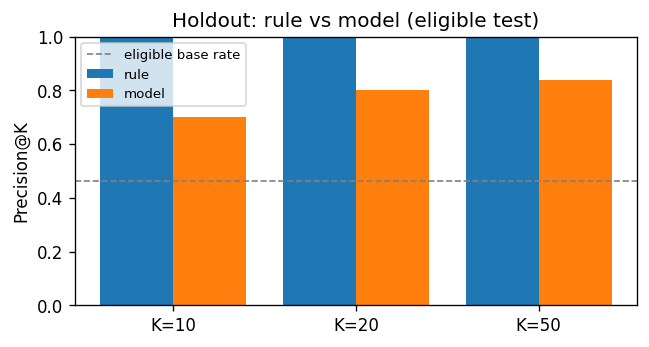

Takeaway: on the eligible holdout pool, the rule hits perfect P@K by design; the model sits between base rate and that ceiling.


In [4]:
results = pd.DataFrame(model_vs["methods"])
bench = pd.DataFrame(playbook["benchmarks"])
display(results)
display(bench)

print("\nSafe claim:")
print(claims["safe_claim"])

p_at_k = FIG / "w07_precision_at_k.png"
if p_at_k.exists():
    display(Image(filename=str(p_at_k)))
    print("Takeaway: on the eligible holdout pool, the rule hits perfect P@K by design; the model sits between base rate and that ceiling.")
else:
    print("Missing figure:", p_at_k)

## 5. Limitations & honest framing

- **Observational only.** No experiment; no causal claim that title/meta edits raise clicks.
- **Proxy label.** Below-tier-median CTR ≠ “broken page.” Zero-click SERPs and tracking gaps can look like title problems.
- **Same-month snapshot.** Features and label both come from March 2026 — a review-now ranking, not a forecast of next month.
- **Sparse GA4.** Engagement is missing for many clients; zeros when tracking is off are excluded from meaning.
- **Queue decays.** Half-month top-50 overlap was only **0.28** — rebuild often; do not treat one queue as permanent.
- **Precision@K vs usefulness.** Perfect baseline Precision@K does not mean the baseline is the best review order for humans.
- **Not Google’s algorithm.** We score pages for reviewer attention; we do not reverse-engineer ranking systems.

Half-month queue decay (from playbook):
{
  "top_50_overlap": 0.28,
  "top_500_overlap": 0.192,
  "rank_corr": 0.48878643313632447
}


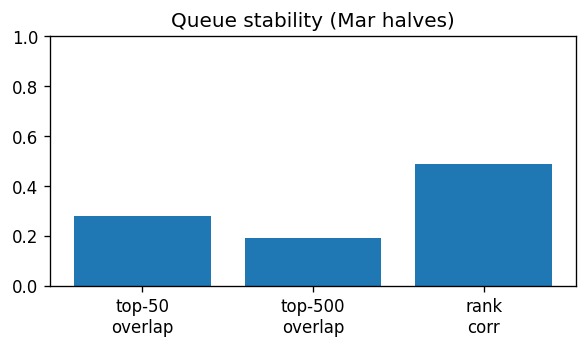

Takeaway: top of the queue moves within the month — treat rankings as perishable.


In [5]:
print("Half-month queue decay (from playbook):")
print(json.dumps(playbook["decay"], indent=2))
stab = FIG / "w07_queue_stability.png"
if stab.exists():
    display(Image(filename=str(stab)))
    print("Takeaway: top of the queue moves within the month — treat rankings as perishable.")
else:
    print("Missing figure:", stab)

## 6. Ranked recommendations (action playbook)

**How an editor should use it tomorrow.** Score the March (or current-month) portfolio with the logistic model. Sort actionable archetypes first, then by model score. Before acting: confirm `imp_mar >= 500`, compare CTR to the **own-tier** median, rule out zero-click SERPs, and verify tracking.

**Archetype → action (all March pages).**  
The five buckets are **mutually exclusive by construction** (fixed if/else order), so the shares add to 100%.

| Archetype | Share of pages | Suggested action |
|---|---:|---|
| high_volume_ctr_gap | ~15% | `review_title_meta` |
| zero_click_visible | ~7% | `check_tracking_first` |
| deep_tier | ~11% | `ranking_not_ctr` (not a CTR fix) |
| thin_volume | ~39% | `monitor_only` |
| healthy | ~28% | `no_action` |

**Cost framing (assumption).** ~15 minutes per review. Model top-50 on holdout ≈ 42 true underperformers vs ≈ 23 at base rate — fewer wasted opens than scanning at random, with room for false alarms.

**No-go list.** Do not auto-publish rewrites; do not prune/merge without a human; do not act on thin-volume pages; do not treat deep-tier as a CTR fix; do not promise click lifts; do not use `ctr_gap` / `trend_*` as model features; do not ship the raw queue as a client audit.

,archetype,pages,action,pct_of_all_pages
0,high_volume_ctr_gap,15135,review_title_meta,14.920003
1,zero_click_visible,7271,check_tracking_first,7.167713
2,deep_tier,11207,ranking_not_ctr,11.047801
3,thin_volume,39517,monitor_only,38.955649
4,healthy,28311,no_action,27.908834


No-go list:
 - auto-publish title/meta rewrites
 - prune / merge / redirect without a human
 - act on thin_volume pages
 - treat deep_tier as a CTR fix
 - promise a click lift to a client
 - use ctr_gap / trend_* as model features
 - send the raw queue to a client as an audit


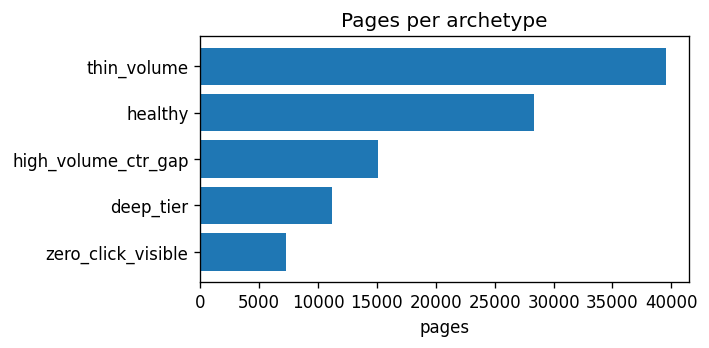

Takeaway: most pages are monitor/healthy; the review budget should focus on high-volume CTR gaps and tracking checks.


In [6]:
arch = pd.DataFrame(playbook["archetype_mix"])
display(arch[["archetype", "pages", "action", "pct_of_all_pages"]])
print("No-go list:")
for item in playbook["no_go"]:
    print(" -", item)

mix = FIG / "w07_archetype_mix.png"
if mix.exists():
    display(Image(filename=str(mix)))
    print("Takeaway: most pages are monitor/healthy; the review budget should focus on high-volume CTR gaps and tracking checks.")
else:
    print("Missing figure:", mix)

## 7. Artifacts the paper embeds

Committed receipts and figures used by the deployed page:

| Path | Role |
|---|---|
| `work/outputs/model_vs_baseline_metrics.json` | Holdout Precision@K table |
| `work/outputs/playbook_metrics.json` | Archetypes, decay, no-go, paper numbers |
| `work/outputs/baseline_metrics.json` | Eligible-pool baseline |
| `work/outputs/validation_leakage_trap.json` | Honest vs leaky AUC |
| `work/outputs/validation_claim_rewrite.json` | Safe claim wording |
| `work/figures/w07_precision_at_k.png` | Model vs rule vs base rate |
| `work/figures/w07_archetype_mix.png` | Action mix |
| `work/figures/w07_queue_stability.png` | Half-month decay |

Upstream notebooks: `w01`–`w07` under `work/notebooks/`. Full prose twin: `work/capstone_report.md`.

In [7]:
artifact_paths = [
    OUT / "model_vs_baseline_metrics.json",
    OUT / "playbook_metrics.json",
    OUT / "baseline_metrics.json",
    OUT / "validation_leakage_trap.json",
    OUT / "validation_claim_rewrite.json",
    FIG / "w07_precision_at_k.png",
    FIG / "w07_archetype_mix.png",
    FIG / "w07_queue_stability.png",
]
status = pd.DataFrame(
    {"path": [str(p.relative_to(ROOT.parent) if ROOT.name == "work" else p) for p in artifact_paths],
     "exists": [p.exists() for p in artifact_paths]}
)
display(status)
assert status["exists"].all(), "Missing paper artifacts — re-run Weeks 5–7 notebooks first."
print("All paper artifacts present.")

,path,exists
0,work\outputs\model_vs_baseline_metrics.json,True
1,work\outputs\playbook_metrics.json,True
2,work\outputs\baseline_metrics.json,True
3,work\outputs\validation_leakage_trap.json,True
4,work\outputs\validation_claim_rewrite.json,True
5,work\figures\w07_precision_at_k.png,True
6,work\figures\w07_archetype_mix.png,True
7,work\figures\w07_queue_stability.png,True


All paper artifacts present.


## 8. Reproducibility

**Repo.** This internship fork (notebooks under `work/notebooks/`).

**Rerun path (fresh clone).**
1. Install deps from the repo `requirements` / environment docs.
2. Set `HF_TOKEN` in `.env` only if you need to rebuild warehouse frames (this capstone notebook does **not** need it — it reads committed JSON/figures).
3. Re-run in order when regenerating: `w03_data_contract` → `w04_baseline_score` → `w05_model` → `w06_validation_audit` → `w07_action_playbook` → `capstone`.
4. Seeds: `random_state=42` for the model and client shuffle (see `model_vs_baseline_metrics.json`).

**Verify this paper draft.** Runtime → Run all on `capstone.ipynb`. Every number quoted above should match the JSON receipts.

## 9. Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

Thanks to the FlyRank internship program for the warehouse release, lane framing, and evaluation standards that keep claims public-safe and decision-support honest.

## ML-12 — Demo outline · social cut · employer summary

### 5-minute demo outline

1. **Question (45s)**  
   FlyRank-style content ops problem: out of many live pages with Google impressions, which ones should a human review first because `ctr` looks weak for their `position_tier` (not just "low CTR")?

2. **Method (90s)**  
   March 2026 warehouse slice (~101k pages; ~62k with `imp_mar >= 500`). Label = `is_ctr_underperformer`. Baseline = rank by `ctr_gap`. Model = logistic regression on `imp_mar`, `ctr_mar`, `pos_avg_mar`, `engagement_rate_mar`, `position_tier`. Evaluate with client holdout.

3. **One chart (60s)**  
   Show Figure 1 (`w07_precision_at_k.png`): base rate vs `ctr_gap` rule vs model Precision@K.

4. **One honest result (60s)**  
   On eligible held-out pages, model P@50 = 0.84 vs base rate 0.464. The `ctr_gap` rule hits 1.00 by design, but its top fills with zero-click pages, and baseline vs model top-10 overlap is 0/10. So the model is not "better Precision@K"; it is a more useful review order.

5. **One recommendation (45s)**  
   Rebuild a monthly queue with the model. Start with `high_volume_ctr_gap` (review title/meta) and `zero_click_visible` (check tracking first). Leave `thin_volume` on monitor-only. Decision support only: do not promise click lifts.

### Social-post cut
We scored ~101k March pages for a FlyRank-style question: which pages get impressions but under-click their Google position tier? A simple `ctr_gap` rule looks perfect on Precision@K, yet packs the top with zero-click pages. A logistic model hit P@50 = 0.84 (base rate 0.46) and built a human review playbook. Decision support, not "we beat Google."

### Employer-facing summary (3 sentences)
I built a ranked review system for weak CTR pages on anonymized FlyRank internship search data (~101k pages in the March 2026 slice). Using a client holdout, logistic regression reached Precision@50 = 0.84 against a 0.46 eligible base rate, while a transparent `ctr_gap` baseline hit perfect Precision@K by construction but ordered zero-click pages first. The output is a content-ops playbook that prioritizes high-impression underperformers for human review, with explicit limits and no causal click-lift claims.

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [X] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [X] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
